<a href="https://colab.research.google.com/github/miftahulhdd/BigData26_B_2411533005_MiftahulHudaAmri/blob/main/praktikum03/BD_P03_2411533005_MiftahulHudaAmri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Langkah ini untuk menyiapkan lingkungan kerja Google Colab, memeriksa versi library yang digunakan, menghubungkan Google Drive, membuat direktori penyimpanan data, serta menyiapkan fungsi pengukuran waktu, penggunaan memori, dan pencatatan data lineage sebagai asal-usul data selama proses praktikum.

In [ ]:
import sys, time, os, json, sqlite3, gc
import pandas as pd, numpy as np, psutil

for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s} : {mod.__version__}")
    except ImportError:
        print(f"{nama:11s} : BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"

for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)

# Dipakai kembali dari Praktikum 1 / K-3
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(rss_mb() - m0, 1)})
    print(f"[{label}] {detik:.2f} s")
    return hasil

# Baru di Praktikum 3: catatan asal-usul data (lineage)
lineage = []

def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama, "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris, "keterangan": keterangan
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")

pandas      : 2.2.3
numpy       : 2.1.3
pyarrow     : 23.0.1
requests    : 2.32.4
sklearn     : 1.6.1
sqlalchemy  : 2.0.54
Mounted at /content/drive


Langkah ini untuk mengunduh data perjalanan dan zona taksi secara aman dengan mekanisme retry, validasi file, dan penulisan atomik, kemudian membaca kolom yang diperlukan serta mencatat sumber dan jumlah baris data melalui data lineage.

In [ ]:
import requests, shutil

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan

    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            f.write(chunk)

            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")

            os.replace(sementara, tujuan) # atomik
            return tujuan

        except Exception as e:
            if os.path.exists(sementara):
                os.remove(sementara)

            if i == percobaan - 1:
                raise

            jeda = jeda_awal * (2 ** i) # exponential backoff
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)

    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")


URL_TRIP = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
URL_ZONA = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

# Hapus file zona lama yang kemungkinan tersimpan dalam bentuk gzip
if os.path.exists(PATH_ZONA):
    os.remove(PATH_ZONA)

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
    print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
         "trip_distance", "PULocationID", "DOLocationID", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(PATH_ZONA)

catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")

zona.head()

[unduh trip] 0.31 s
[unduh zona] 0.02 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.01 MB
[baca trip] 0.94 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


Langkah ini untuk mengambil data cuaca per jam melalui API Open-Meteo, melakukan validasi respons dan retry saat terjadi gangguan, kemudian mengubah format waktu serta nama kolom agar siap digunakan dalam proses analisis.

In [ ]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    parameter = {
        "latitude": lat, "longitude": lon,
        "start_date": mulai, "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data: #validasi struktur
                raise ValueError("kunci 'hourly' tidak ada pada respons")
            return pd.DataFrame(data["hourly"])

        if r.status_code in (429, 500, 502, 503): # layak dicoba ulang
            time.sleep(2 ** i)
            continue
        r.raise_for_status()
    # galat lain: hentikan
    raise RuntimeError("API cuaca tidak merespons dengan benar")

cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))
cuaca["time"] = pd.to_datetime(cuaca["time"])

cuaca = cuaca.rename(columns={
    "time": "jam_mulai",
    "temperature_2m": "suhu_c",
    "precipitation": "hujan_mm"
})

catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")
cuaca.head()

[ambil cuaca] 0.67 s
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


Langkah ini untuk membuat database SQLite sebagai sumber data operasional, menyimpan tabel referensi metode pembayaran dan data transaksi perjalanan, serta melakukan agregasi dan pembacaan data secara bertahap untuk mengurangi penggunaan memori.

In [ ]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                        "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# tabel transaksi tiruan untuk latihan pembacaan bertahap
trip.head(300_000).to_sql(
    "trip_operasional", engine, if_exists="replace",
    index=False, chunksize=50_000)

print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine)["name"].tolist())

SQL = """
SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
FROM trip_operasional
WHERE total_amount > 0
GROUP BY payment_type
ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap: agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional",
                          engine, chunksize=50_000):
    total_baris += len(bagian)
print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi),
             "tabel dimensi dari basis data operasional")

Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


Langkah ini untuk membuat profil data, menghitung durasi perjalanan, serta memeriksa kualitas data berdasarkan kelengkapan, keunikan, validitas, konsistensi, dan ketepatan waktu untuk mengidentifikasi data yang tidak memenuhi aturan.

In [ ]:
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60)

def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]
        baris.append({
            "kolom": kol, "tipe": str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),
            "nilai_unik": s.nunique(dropna=True),
            "contoh": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)

profil = profil_kolom(trip)
profil

,kolom,tipe,persen_hilang,nilai_unik,contoh
0,tpep_pickup_datetime,datetime64[us],0.000,1610975,2023-01-01 00:32:10
1,tpep_dropoff_datetime,datetime64[us],0.000,1611319,2023-01-01 00:40:36
2,passenger_count,float64,2.339,10,1.0
3,trip_distance,float64,0.000,4387,0.97
4,PULocationID,int64,0.000,257,161
5,DOLocationID,int64,0.000,261,141
6,payment_type,int64,0.000,5,2
7,fare_amount,float64,0.000,6873,9.3
8,tip_amount,float64,0.000,4036,0.0
9,total_amount,float64,0.000,15871,14.3


In [ ]:
AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])

aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0-100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}

laporan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)

laporan

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


Langkah ini untuk menangani missing value pada passenger_count dengan membandingkan beberapa strategi, kemudian memilih pengisian median berdasarkan jam perjalanan serta menghapus data duplikat berdasarkan kunci transaksi.

In [ ]:
KOL = "passenger_count"
asli = trip[KOL]
print("persen hilang:", round(100 * asli.isna().mean(), 3))

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour

strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}

banding = pd.DataFrame([
    {"strategi": nama, "n": len(s), "mean": round(s.mean(), 4),
     "median": s.median(), "std": round(s.std(), 4)}
    for nama, s in strategi.items()
])
banding

persen hilang: 2.339


,strategi,n,mean,median,std
0,1_dibuang,2995023,1.3625,1.0,0.8961
1,2_isi_median,3066766,1.3541,1.0,0.8873
2,3_isi_modus,3066766,1.3541,1.0,0.8873
3,4_median_perjam,3066766,1.3541,1.0,0.8873


In [ ]:
# Strategi yang dipilih modul ini: tandai + isi per kelompok (lihat G.4)
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(trip.groupby("jam")[KOL].transform("median"))
trip[KOL] = trip[KOL].fillna(trip[KOL].median()) # jaring pengaman

# Duplikat: periksa dua tingkat
dup_penuh = trip.duplicated().sum()
KUNCI = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "PULocationID", "DOLocationID", "total_amount"]
dup_kunci = trip.duplicated(subset=KUNCI).sum()

print(f"duplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"{sebelum:,} -> {len(trip):,} baris")

duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


Langkah ini untuk mendeteksi dan menangani outlier menggunakan metode IQR dan Z-score, menyaring data yang tidak layak, serta melakukan join dengan tabel zona, metode pembayaran, dan data cuaca untuk melengkapi informasi perjalanan.

In [ ]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()
        hasil.append({
            "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3": int((z.abs() > 3).sum()),
            "p99": round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"])

,kolom,batas_bawah,batas_atas,outlier_iqr,outlier_z3,p99
0,trip_distance,-2.35,6.74,390244,67,20.06
1,durasi_menit,-9.66,35.08,170615,3175,57.25
2,total_amount,-4.55,48.65,371616,87248,101.94


In [ ]:
# Tindakan berbeda untuk maksud berbeda (lihat G.5)
layak = (
    (trip["trip_distance"].between(0.01, 100)) &
    (trip["durasi_menit"].between(1, 180)) &
    (trip["total_amount"] > 0)
)
bersih = trip.loc[layak].copy()

# tandai, jangan buang: outlier bisa jadi memang kenyataan bisnis
lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

# winsorizing hanya untuk kolom turunan yang akan dipakai model
batas_atas = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)

print(f"{len(trip):,} -> {len(bersih):,} baris "
      f"({100 * (1 - len(bersih)/len(trip)):.2f}% dibuang)")

# Join 1: tabel zona (dimensi)
print("kunci zona unik?", zona["LocationID"].is_unique) # WAJIB diperiksa
n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
    .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one"
)
bersih = bersih.drop(columns="LocationID")
# gagal keras bila tidak 1:1
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tak dikenal:", bersih["zona_naik"].isna().sum())

# Join 2: tabel pembayaran dari basis data
bersih = bersih.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                      on="payment_type", how="left", validate="many_to_one")

# Join 3: cuaca, berdasarkan jam (tingkat rincian harus disamakan dulu)
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0 = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())

3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


Langkah ini untuk membuat fitur turunan perjalanan dan melakukan prapemrosesan data dengan StandardScaler untuk fitur numerik serta OneHotEncoder untuk fitur kategorikal, dengan proses fitting hanya pada data latih untuk mencegah kebocoran data.

In [ ]:
bersih["hari_minggu"] = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"] = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"] / bersih["trip_distance"]).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42)

latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)

skala = StandardScaler().fit(latih[FITUR_NUM]) # fit HANYA di data latih
latih_num = skala.transform(latih[FITUR_NUM])
uji_num = skala.transform(uji[FITUR_NUM])      # transform saja, tanpa fit ulang

print("mean latih (harus ~0):", latih_num.mean(axis=0).round(3))
print("mean uji (tidak harus 0):", uji_num.mean(axis=0).round(3))

# Bergantung versi: parameter sparse_output ada sejak scikit-learn 1.2
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])

print("jumlah kolom hasil one-hot:", latih_kat.shape[1])
print("nama kolom:", enc.get_feature_names_out()[:6], "...")

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


Langkah ini untuk membangun pipeline pengolahan data yang idempoten, melakukan validasi struktur dan kualitas data, menyimpan hasil dalam format Parquet berpartisi, serta menghasilkan artefak berupa laporan kualitas, data lineage, pengukuran kinerja, dan arsip data bersih.

In [ ]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]", "trip_distance": "float64",
    "durasi_menit": "float64", "total_amount": "float64",
    "borough_naik": "object", "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")

    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")

    if masalah:
        raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
    print(f"Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
    return df

validasi(bersih)

def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
    df = pd.read_parquet(path_trip, columns=KOLOM)
    z = pd.read_csv(path_zona)

    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                          .dt.total_seconds() / 60)
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median"))

    df = df.drop_duplicates(subset=KUNCI)
    df = df[
        (df["trip_distance"].between(0.01, 100)) &
        (df["durasi_menit"].between(1, 180)) &
        (df["total_amount"] > 0)
    ]

    df = (df.merge(z[["LocationID", "Borough"]]
                   .rename(columns={"Borough": "borough_naik"}),
                   left_on="PULocationID", right_on="LocationID",
                   how="left", validate="many_to_one")
            .drop(columns="LocationID")
            .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                   on="payment_type", how="left", validate="many_to_one"))

    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")

    return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))
OUT = os.path.join(DIR_KURASI, "trips_bersih")
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)

ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False))
print("partisi yang terbentuk:", sorted(os.listdir(OUT))[5], "...")

# Bukti idempotensi: jalankan ulang, hasil harus identik
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("idempoten?", len(ulang) == len(hasil))

# Artefak yang dikumpulkan
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)

Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 14.22 s
[tulis parquet berpartisi] 5.12 s
partisi yang terbentuk: borough_naik=Staten%20Island ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

Langkah ini untuk mengolah data perjalanan menggunakan Apache Spark, melakukan penyaringan dan penghapusan duplikat, menggabungkan data zona dengan broadcast join, menghitung jumlah data bersih, serta menyimpan hasil dalam Parquet yang dipartisi berdasarkan wilayah.

In [ ]:
!pip install -q pyspark==3.5.1
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("BD-P02").master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (sdf
    .withColumn("durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime")
         - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter(F.col("trip_distance").between(0.01, 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
    .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                      "PULocationID", "DOLocationID", "total_amount"])
    .join(F.broadcast(szona),  # tabel kecil: broadcast
          sdf.PULocationID == szona.LocationID, "left")
    .drop("LocationID"))

ukur("spark: hitung baris bersih", lambda: sbersih.count())
sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

sbersih.write.mode("overwrite").partitionBy("Borough") \
    .parquet("/content/lapisan_terkurasi/trips_spark")

sbersih.explain()  # cari BroadcastHashJoin, bukan SortMergeJoin
spark.stop()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 9.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[spark: hitung baris bersih] 16.29 s
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#245, trip_distance#247, PULocationID#7L, DOLocation

In [ ]:
!pyspark --version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /___/ .__/\_,_/_/ /_/\_\   version 3.5.1
      /_/
                        
Using Scala version 2.12.18, OpenJDK 64-Bit Server VM, 21.0.12
Branch HEAD
Compiled by user heartsavior on 2024-02-15T11:24:58Z
Revision fd86f85e181fc2dc0f50a096855acf

o.4

In [ ]:
# O.4 — versi pipeline() dengan pengukuran waktu per tahap (khusus untuk analisis biaya)
# Tidak menggantikan pipeline() asli di K-10; hanya dipakai untuk diagnosis O.4.

catatan_rinci = []

def _ukur_rinci(label, fungsi):
    t0 = time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan_rinci.append({"tahap": label, "detik": round(detik, 3)})
    print(f"[{label}] {detik:.3f} s")
    return hasil

def pipeline_terinstrumentasi(path_trip, path_zona, df_cuaca, df_tarif):
    df = _ukur_rinci("1. baca parquet+csv",
                      lambda: (pd.read_parquet(path_trip, columns=KOLOM), pd.read_csv(path_zona)))
    df, z = df

    def transform():
        d = df.copy()
        d["durasi_menit"] = ((d["tpep_dropoff_datetime"] - d["tpep_pickup_datetime"])
                              .dt.total_seconds() / 60)
        d["jam"] = d["tpep_pickup_datetime"].dt.hour
        d["passenger_count"] = d["passenger_count"].fillna(
            d.groupby("jam")["passenger_count"].transform("median"))
        d = d.drop_duplicates(subset=KUNCI)
        d = d[(d["trip_distance"].between(0.01, 100))
              & (d["durasi_menit"].between(1, 180))
              & (d["total_amount"] > 0)]
        return d

    d = _ukur_rinci("2. transformasi + filter + dedup", transform)

    def gabung():
        hasil = (d.merge(z[["LocationID", "Borough"]]
                          .rename(columns={"Borough": "borough_naik"}),
                          left_on="PULocationID", right_on="LocationID",
                          how="left", validate="many_to_one")
                   .drop(columns="LocationID")
                   .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                          on="payment_type", how="left", validate="many_to_one"))
        hasil["jam_mulai"] = hasil["tpep_pickup_datetime"].dt.floor("h")
        hasil = hasil.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")
        return hasil

    hasil = _ukur_rinci("3. tiga join (zona+tarif+cuaca)", gabung)
    return validasi(hasil)

hasil_diagnosa = pipeline_terinstrumentasi(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)

rincian_waktu = pd.DataFrame(catatan_rinci)
rincian_waktu["persen"] = round(100 * rincian_waktu["detik"] / rincian_waktu["detik"].sum(), 1)
rincian_waktu

[1. baca parquet+csv] 0.751 s
[2. transformasi + filter + dedup] 2.769 s
[3. tiga join (zona+tarif+cuaca)] 2.845 s
Validasi lulus: 2,986,910 baris x 17 kolom


,tahap,detik,persen
0,1. baca parquet+csv,0.751,11.8
1,2. transformasi + filter + dedup,2.769,43.5
2,3. tiga join (zona+tarif+cuaca),2.845,44.7


o.5

In [ ]:
# O.5 — investigasi penyebab & konsentrasi baris tanpa pasangan zona

# 1) Apakah PULocationID yang gagal join benar-benar tidak ada di tabel zona,
#    ataukah match ke entri zona yang field Zone-nya kosong (mis. LocationID 264/265)?
gagal_zona = bersih[bersih["zona_naik"].isna()]
print("PULocationID pada baris gagal (10 paling sering):")
print(gagal_zona["PULocationID"].value_counts().head(10))

print("\nEntri di taxi_zone_lookup.csv dengan Zone kosong:")
print(zona[zona["Zone"].isna()])

print("\nEntri di taxi_zone_lookup.csv untuk LocationID 264 & 265 (jika ada):")
print(zona[zona["LocationID"].isin([264, 265])])

# 2) Apakah baris gagal terkonsentrasi pada jam tertentu?
print("\nDistribusi per jam pada baris gagal zona (top 5):")
print(gagal_zona["tpep_pickup_datetime"].dt.hour.value_counts().head(5))

# 3) Baris tanpa pasangan cuaca -- periksa apakah terkonsentrasi di jam tertentu
# (mis. di ujung awal/akhir rentang tanggal permintaan API)
gagal_cuaca = bersih[bersih["suhu_c"].isna()]
print("\nJam_mulai pada baris tanpa data cuaca:")
print(gagal_cuaca["jam_mulai"].describe())

PULocationID pada baris gagal (10 paling sering):
PULocationID
264    37609
Name: count, dtype: int64

Entri di taxi_zone_lookup.csv dengan Zone kosong:
     LocationID  Borough Zone service_zone
263         264  Unknown  NaN          NaN

Entri di taxi_zone_lookup.csv untuk LocationID 264 & 265 (jika ada):
     LocationID  Borough            Zone service_zone
263         264  Unknown             NaN          NaN
264         265      NaN  Outside of NYC          NaN

Distribusi per jam pada baris gagal zona (top 5):
tpep_pickup_datetime
14    2702
19    2470
17    2453
18    2383
13    2296
Name: count, dtype: int64

Jam_mulai pada baris tanpa data cuaca:
count                            37
mean     2023-01-03 19:34:03.243243
min             2022-10-25 00:00:00
25%             2022-12-31 23:00:00
50%             2022-12-31 23:00:00
75%             2023-02-01 00:00:00
max             2023-02-01 00:00:00
Name: jam_mulai, dtype: object


grafik perbandingan

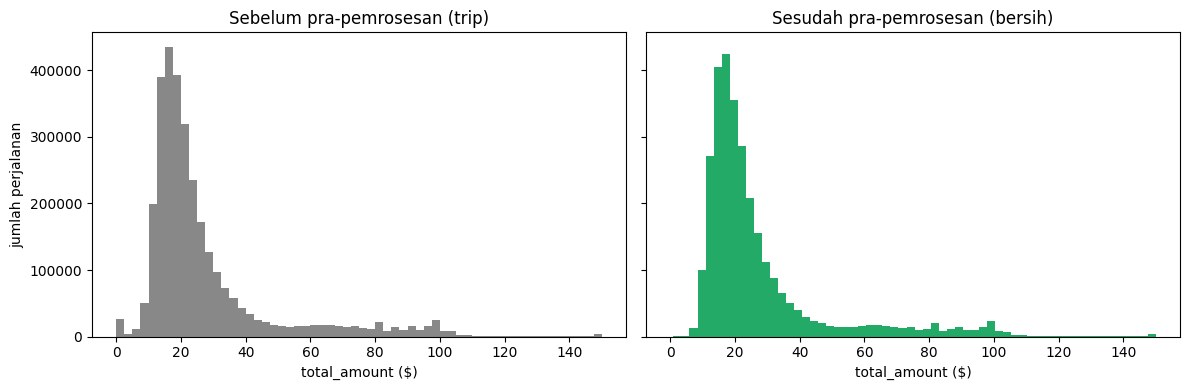

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

batas = (0, 150)  # dipotong agar histogram terbaca; ekor ekstrem tetap ada di data asli

axes[0].hist(trip["total_amount"].clip(*batas), bins=60, color="#888")
axes[0].set_title("Sebelum pra-pemrosesan (trip)")
axes[0].set_xlabel("total_amount ($)")
axes[0].set_ylabel("jumlah perjalanan")

axes[1].hist(bersih["total_amount"].clip(*batas), bins=60, color="#2a6")
axes[1].set_title("Sesudah pra-pemrosesan (bersih)")
axes[1].set_xlabel("total_amount ($)")

plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/perbandingan_total_amount.png", dpi=120)
plt.show()

studi kasus

In [ ]:
tabel_analitik = (bersih
    .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
    .groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_tarif_per_mil=("tarif_per_mil", "median"),
         rata_kecepatan=("kecepatan_mph", "median"),
         suhu_c=("suhu_c", "first"), hujan=("hujan", "max"))
    .reset_index())

# Ambang minimum: kelompok yang terlalu kecil tidak bisa disimpulkan
tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"] >= 30]

pivot_hujan = (tabel_analitik
    .groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"]
    .median().unstack())
print(pivot_hujan)

# Simpan artefak studi kasus
tabel_analitik.to_parquet(f"{DIR_SIMPAN}/tabel_analitik_pricing.parquet", index=False)
print(f"\ntersimpan: {DIR_SIMPAN}/tabel_analitik_pricing.parquet ({len(tabel_analitik):,} baris)")

hujan               0        1
borough_naik                  
Brooklyn       6.9430   7.6550
Manhattan     10.5270  11.4000
Queens         5.4530   5.6365
Unknown        8.7255   9.8860

tersimpan: /content/drive/MyDrive/BigData/Praktikum3/tabel_analitik_pricing.parquet (2,094 baris)


latihan

q.1

In [ ]:
def unduh_aman_v2(url, tujuan, percobaan=3, jeda_awal=2):
    """Versi unduh_aman yang mencetak kecepatan unduh dalam MB/detik."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan), "-> tidak mengunduh ulang")
        return tujuan

    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            t0 = time.perf_counter()
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            f.write(chunk)
            detik = time.perf_counter() - t0
            ukuran_mb = os.path.getsize(sementara) / 1024**2
            if ukuran_mb == 0:
                raise IOError("berkas kosong")
            kecepatan = ukuran_mb / detik if detik > 0 else float("inf")
            print(f"unduh selesai: {ukuran_mb:.2f} MB dalam {detik:.2f} s "
                  f"({kecepatan:.2f} MB/s)")
            os.replace(sementara, tujuan)
            return tujuan
        except Exception as e:
            if os.path.exists(sementara):
                os.remove(sementara)
            if i == percobaan - 1:
                raise
            jeda = jeda_awal * (2 ** i)
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)

# Panggilan pertama (kemungkinan besar sudah cache karena K-2 sudah dijalankan)
unduh_aman_v2(URL_ZONA, PATH_ZONA)
# Panggilan kedua -- HARUS memakai cache
unduh_aman_v2(URL_ZONA, PATH_ZONA)

cache ditemukan: taxi_zone_lookup.csv -> tidak mengunduh ulang
cache ditemukan: taxi_zone_lookup.csv -> tidak mengunduh ulang


'/content/lapisan_mentah/taxi_zone_lookup.csv'

q.2

In [ ]:
aturan_tambahan = dict(aturan)  # salin aturan K-6 sebagai dasar
aturan_tambahan["validitas: tip_amount >= 0"] = trip["tip_amount"] >= 0
aturan_tambahan["konsistensi: dropoff > pickup"] = (
    trip["tpep_dropoff_datetime"] > trip["tpep_pickup_datetime"])

laporan_tambahan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan_tambahan.items()
]).sort_values("persen_gagal", ascending=False)

laporan_tambahan

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
9,konsistensi: dropoff > pickup,3065644,1121,0.037
8,validitas: tip_amount >= 0,3066540,225,0.007
7,ketepatan waktu dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


q.3

In [ ]:
bersih_tujuan = bersih.merge(
    zona[["LocationID", "Borough"]].rename(columns={"Borough": "borough_tujuan"}),
    left_on="DOLocationID", right_on="LocationID",
    how="left", validate="many_to_one")
bersih_tujuan = bersih_tujuan.drop(columns="LocationID")

pasangan_tersibuk = (bersih_tujuan
    .groupby(["borough_naik", "borough_tujuan"], observed=True)
    .size()
    .reset_index(name="jumlah_perjalanan")
    .sort_values("jumlah_perjalanan", ascending=False)
    .head(10))

pasangan_tersibuk

,borough_naik,borough_tujuan,jumlah_perjalanan
22,Manhattan,Manhattan,2491566
29,Queens,Manhattan,155261
23,Manhattan,Queens,82354
20,Manhattan,Brooklyn,62986
30,Queens,Queens,59146
27,Queens,Brooklyn,42187
42,Unknown,Manhattan,18432
45,Unknown,Unknown,13562
19,Manhattan,Bronx,8865
8,Brooklyn,Brooklyn,7910


q.4

In [ ]:
from sklearn.preprocessing import MinMaxScaler

skala_minmax = MinMaxScaler().fit(latih[FITUR_NUM])  # fit HANYA di data latih
latih_minmax = skala_minmax.transform(latih[FITUR_NUM])
uji_minmax = skala_minmax.transform(uji[FITUR_NUM])

banding_scaler = pd.DataFrame({
    "fitur": FITUR_NUM,
    "standard_min": latih_num.min(axis=0).round(3),
    "standard_max": latih_num.max(axis=0).round(3),
    "minmax_min": latih_minmax.min(axis=0).round(3),
    "minmax_max": latih_minmax.max(axis=0).round(3),
})
banding_scaler

,fitur,standard_min,standard_max,minmax_min,minmax_max
0,trip_distance_capped,-0.794,4.247,0.0,1.0
1,durasi_menit,-1.226,13.925,0.0,1.0
2,suhu_c,-2.288,3.347,0.0,1.0


q.5

In [ ]:
zona_rusak = pd.concat([zona, zona.iloc[[0]]], ignore_index=True)  # duplikasi baris pertama
print("kunci zona (rusak) unik?", zona_rusak["LocationID"].is_unique)

try:
    _ = bersih.merge(
        zona_rusak[["LocationID", "Borough", "Zone"]]
        .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
        left_on="PULocationID", right_on="LocationID",
        how="left", validate="many_to_one")
    print("TIDAK terjadi error -- seharusnya terjadi!")
except Exception as e:
    print(f"Error seperti yang diharapkan: {type(e).__name__}: {e}")

# zona_rusak hanya salinan sementara; `zona` yang asli tidak pernah diubah,
# jadi tidak perlu proses "mengembalikan" apa pun selain membuang salinannya.
del zona_rusak

kunci zona (rusak) unik? False
Error seperti yang diharapkan: MergeError: Merge keys are not unique in right dataset; not a many-to-one merge


q.6

In [ ]:
def bulan_sudah_ada(direktori_out, bulan):
    """Cek apakah data untuk bulan (format 'YYYY-MM') sudah ada di keluaran."""
    if not os.path.isdir(direktori_out):
        return False
    df_ada = pd.read_parquet(direktori_out, columns=["tanggal"])
    if df_ada.empty:
        return False
    bulan_ada = pd.to_datetime(df_ada["tanggal"]).dt.strftime("%Y-%m").unique()
    return bulan in bulan_ada

def pipeline_inkremental(bulan, direktori_out=OUT, dir_mentah=DIR_MENTAH):
    """Memproses satu bulan (format 'YYYY-MM') hanya jika belum ada di keluaran."""
    if bulan_sudah_ada(direktori_out, bulan):
        print(f"bulan {bulan} sudah ada di {direktori_out}; dilewati (idempoten)")
        return None

    url = (f"https://d37ci6vzurychx.cloudfront.net/trip-data/"
           f"yellow_tripdata_{bulan}.parquet")
    path_trip_bulan = os.path.join(dir_mentah, f"yellow_tripdata_{bulan}.parquet")
    unduh_aman(url, path_trip_bulan)

    df_bulan = pipeline(path_trip_bulan, PATH_ZONA, cuaca, tarif_referensi)
    df_bulan["tanggal"] = df_bulan["tpep_pickup_datetime"].dt.date.astype(str)

    file_sebelum = set(os.listdir(direktori_out)) if os.path.isdir(direktori_out) else set()
    df_bulan.to_parquet(direktori_out, partition_cols=["borough_naik"], index=False)
    file_sesudah = set(os.listdir(direktori_out))
    print(f"bulan {bulan} ditulis: {len(df_bulan):,} baris "
          f"({len(file_sesudah - file_sebelum)} entri direktori baru)")
    return df_bulan

# Bukti idempotensi: panggilan kedua tidak menghasilkan berkas baru
hasil_1 = pipeline_inkremental("2023-01")
hasil_2 = pipeline_inkremental("2023-01")  # seharusnya dilewati

bulan 2023-01 sudah ada di /content/lapisan_terkurasi/trips_bersih; dilewati (idempoten)
bulan 2023-01 sudah ada di /content/lapisan_terkurasi/trips_bersih; dilewati (idempoten)


In [ ]:
# import time

# menit = 0
# print("Menjaga runtime... Tekan tombol Stop (◼) di samping sel untuk mematikan.")

# try:
#     while True:
#         # Kode akan terus berulang di dalam blok ini
#         time.sleep(60)
#         menit += 1
#         print(f"Menjaga runtime tetap aktif... ({menit} menit berlalu)")

# except KeyboardInterrupt:
#     # Blok ini akan tereksekusi saat Anda menekan tombol Stop
#     print(f"\n✅ Perulangan dihentikan secara manual. Total waktu berjalan: {menit} menit.")

Menjaga runtime... Tekan tombol Stop (◼) di samping sel untuk mematikan.
Menjaga runtime tetap aktif... (1 menit berlalu)
Menjaga runtime tetap aktif... (2 menit berlalu)
Menjaga runtime tetap aktif... (3 menit berlalu)
Menjaga runtime tetap aktif... (4 menit berlalu)
Menjaga runtime tetap aktif... (5 menit berlalu)
Menjaga runtime tetap aktif... (6 menit berlalu)
Menjaga runtime tetap aktif... (7 menit berlalu)
Menjaga runtime tetap aktif... (8 menit berlalu)
Menjaga runtime tetap aktif... (9 menit berlalu)
Menjaga runtime tetap aktif... (10 menit berlalu)
Menjaga runtime tetap aktif... (11 menit berlalu)
Menjaga runtime tetap aktif... (12 menit berlalu)
Menjaga runtime tetap aktif... (13 menit berlalu)
Menjaga runtime tetap aktif... (14 menit berlalu)
Menjaga runtime tetap aktif... (15 menit berlalu)
Menjaga runtime tetap aktif... (16 menit berlalu)
Menjaga runtime tetap aktif... (17 menit berlalu)
Menjaga runtime tetap aktif... (18 menit berlalu)
Menjaga runtime tetap aktif... (19 m